🔍 총 19956개 파일 정합성(Integrity) 검증 시작...


  0%|          | 0/19956 [00:00<?, ?it/s]

✔ 검증 완료. 불량 파일(Invalid): 0개


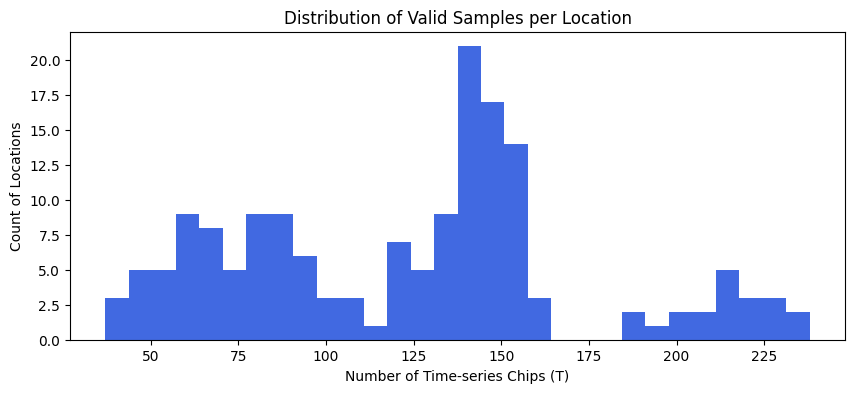

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# 1. 상대 경로 설정 (notebooks -> 프로젝트 루트 -> rawData)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
CHIP_DIR = os.path.join(BASE_DIR, 'rawData', 'chips')
EXPECTED_SHAPE = (5, 32, 32)

# 2. 파일 리스트 확보
file_list = glob.glob(f'{CHIP_DIR}/loc_*/*.npy')
results = []

print(f"🔍 총 {len(file_list)}개 파일 정합성(Integrity) 검증 시작...")

# 3. 전수 조사
for f in tqdm(file_list):
    try:
        data = np.load(f)
        shape = data.shape
        # 인터페이스 명세(Interface Specification) 확인
        is_valid = (shape == EXPECTED_SHAPE)
    except Exception:
        shape = None
        is_valid = False
    
    results.append({
        'path': os.path.relpath(f, BASE_DIR), # 루트 기준 상대 경로로 저장
        'loc_id': f.split(os.sep)[-2],
        'shape': shape,
        'is_valid': is_valid
    })

df = pd.DataFrame(results)

# 4. 결과 요약 출력
invalid_count = len(df[~df['is_valid']])
print(f"✔ 검증 완료. 불량 파일(Invalid): {invalid_count}개")

# 5. 지점별 시계열 데이터 밀도 시각화
plt.figure(figsize=(10, 4))
df[df['is_valid']].groupby('loc_id').size().hist(bins=30, color='royalblue', grid=False)
plt.title('Distribution of Valid Samples per Location')
plt.xlabel('Number of Time-series Chips (T)')
plt.ylabel('Count of Locations')
plt.show()